# Preprocessing

In questo notebook verranno eseguite tutte le attività di preprocessing del dataset.
Ogni split/preprocessamento dei dati sarà salvato nella cartella apposita "data/processed".

## Download dataset

Scarichiamo il dataset con il codice fornito direttamente da *kaggle*

In [1]:
import kagglehub

# Download diretta da kaggle
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\ledoa\.cache\kagglehub\datasets\msambare\fer2013\versions\1


## Visualizzazione immagini

Visualizziamo 12 immagini assieme alle rispettive etichette per farci un'idea delle immagini che compongono il dataset 

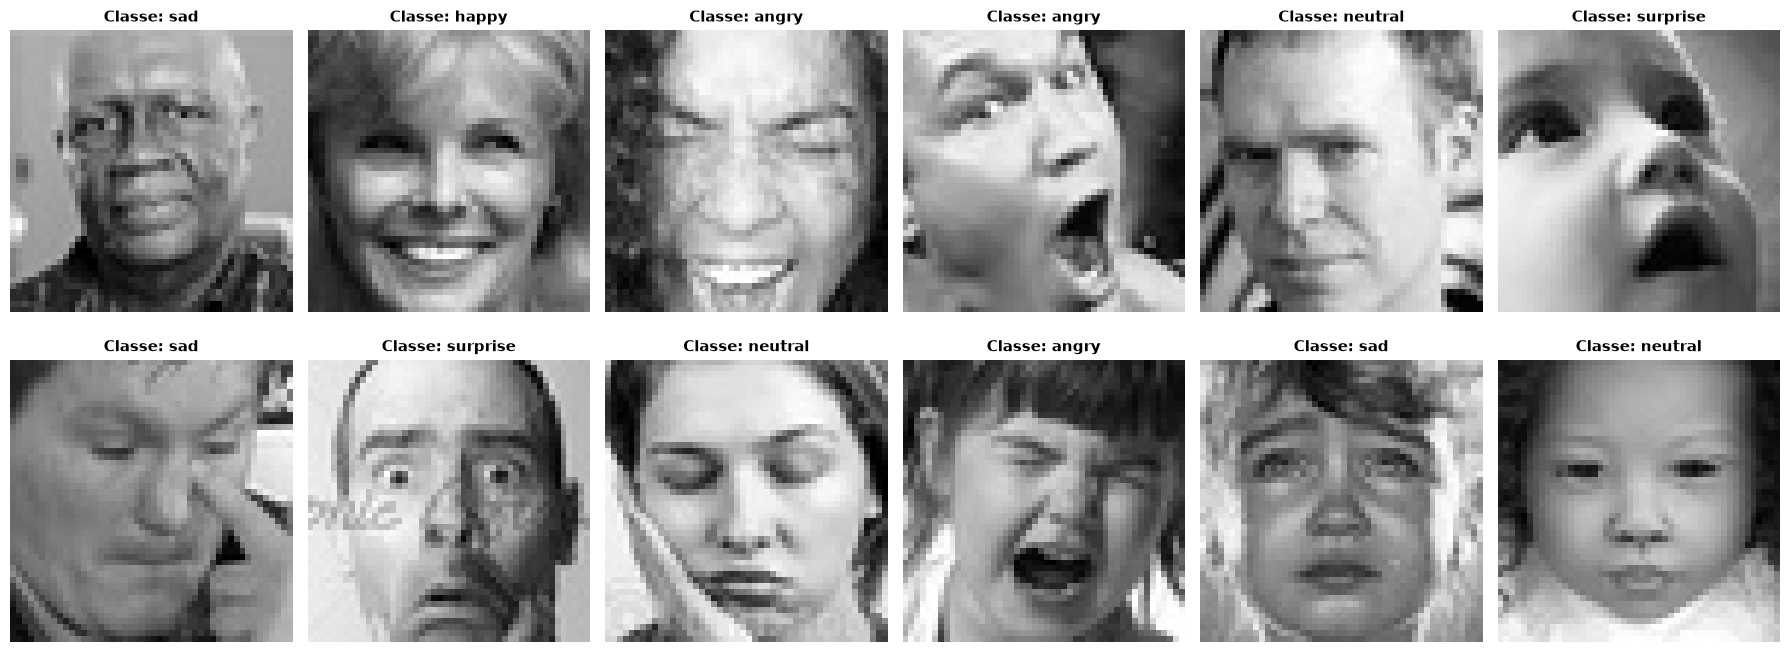

In [2]:

import random
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image


dataset_path = Path(path)

valid_extensions = [".jpg"]
all_images = [
    p for p in dataset_path.rglob("*") if p.suffix.lower() in valid_extensions
]

if not all_images:
    print(
        f"Nessuna immagine presente nel percorso: {dataset_path}"
    )
else:
    num_samples = 12
    samples = random.sample(all_images, min(num_samples, len(all_images)))

    num_rows = 2
    num_cols = 6

    plt.figure(figsize=(18, 7))

    for idx, img_path in enumerate(samples):
        emotion_class = img_path.parent.name
        title = f"Classe: {emotion_class}"

        img = Image.open(img_path)

        plt.subplot(num_rows, num_cols, idx + 1)

        plt.imshow(img, cmap="gray" if img.mode == "L" else None)
        plt.title(title, fontsize=11, fontweight="bold")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## Preprocessing

Utilizziamo una funzione per applicare delle leggere modifice alle immagini per generare più campioni.
Le tecniche di preprocessing che andremo ad applicare sono:
- Flip orizzontale
- Traslazione
- Rotazione
- Zoom
- Normalizzazione 

### Funzione per il preprocessing delle immagini

In [3]:
import torchvision.transforms as transforms

# Pipeline per preprocessing
def get_preprocessing_pipeline():
    preprocessing = transforms.Compose(
        [
            # 1. Flip Orizzontale casuale
            transforms.RandomHorizontalFlip(p=0.5),
            
            # 2. Rotazione casuale
            transforms.RandomRotation(degrees=15, fill=0),
            
            # 3. Traslazione e Zoom leggero
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), fill=0),
            
            # Conversione in tensore
            transforms.ToTensor(),
            
            # 5. Normalizzazione
            #transforms.Normalize(mean=[0.5], std=[0.5])
        ]
    )
    return preprocessing

In [4]:
# Utilizziamo una funzione per rilevare il percorso del pc
# Così si evitano problemi con l'utilizzo di altri pc 

import os

def get_wd():
    notebook_dir = Path(os.getcwd())

    project_root = notebook_dir.parent

    final_path = project_root / "data"

    return Path(final_path)

#print(get_wd())

### Preprocessing

In [5]:
import random
from pathlib import Path
from PIL import Image
import torchvision.transforms as transforms

data_root = get_wd()

dataset_originale_path = data_root / "original" / "train"
print(dataset_originale_path)
dataset_processed_path = data_root / "processed"


pipeline = get_preprocessing_pipeline()

# Conversione da tensore a immagine normale 
def tensor_to_saved_image(tensor):
    tensor = tensor * 0.5 + 0.5
    tensor = tensor.clamp(0, 1) 
    reverse_transform = transforms.ToPILImage()
    return reverse_transform(tensor)


# Controllo dell'estensione dei file (le immagini del dataset sono tutte in .jpg)
valid_extensions = [".jpg"]
all_images = [p for p in dataset_originale_path.rglob("*") if p.suffix.lower() in valid_extensions]


# Prendiamo il 40% delle immagini di training
percentuale_da_prendere = 0.40
num_immagini_da_preprocessare = int(len(all_images) * percentuale_da_prendere)
immagini_selezionate = random.sample(all_images, num_immagini_da_preprocessare)

print(f"Inizio elaborazione di {num_immagini_da_preprocessare} immagini...")

for img_path in immagini_selezionate:
    
    # Prendiamo il nome della cartella per mantenere le label per le immagini preprocessate
    relativo_path = img_path.relative_to(dataset_originale_path)
    
    # Diamo il nuovo percorso (processed) in cui andranno salvate le immagini
    nuovo_percorso_file = dataset_processed_path / relativo_path
    
    # Nel caso in cui manchino le cartelle le creiamo
    # Una volta create questa sezione controllerà solo se esistono
    nuovo_percorso_file.parent.mkdir(parents=True, exist_ok=True)
    
    # Modifica del nome dei file per evitare problemi futuri
    nuovo_percorso_file = nuovo_percorso_file.with_name(f"{img_path.stem}_processed{img_path.suffix}")

    try:
        # Si apre l'immagine
        img_originale = Image.open(img_path)
        
        # Si applicano le modifiche con PyTorch
        img_tensor = pipeline(img_originale)
        
        # Conversione da tensore per evitare problemi di lettura (dato che non si possono visualizzare le immagini se sono tensori)
        img_da_salvare = tensor_to_saved_image(img_tensor)
        
        # Vengono salvati nella cartella 'processed' dentro la sottocartella corretta (la label)
        img_da_salvare.save(nuovo_percorso_file)
        
    # In caso di problemi
    except Exception as e:
        print(f"Errore con il file {img_path.name}: {e}")

print(f"Dati preprocessati correttamente")

c:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\data\original\train
Inizio elaborazione di 11483 immagini...
Dati preprocessati correttamente


### Split del dataset

##### Split virtuale del dataset

Il dataset FER-2013 contiene già una cartella `train` e una cartella `test`.
Per evitare di copiare file o creare nuove cartelle, usiamo `validation_split` sul training set:
- `train`: usato per addestramento e validazione
- `test`: mantenuto separato per la valutazione finale

In [6]:
from pathlib import Path
from tensorflow.keras.preprocessing.image import ImageDataGenerator

current_dir = Path.cwd()
project_root = current_dir if (current_dir / "data" / "original").exists() else current_dir.parent

train_dir = project_root / "data" / "original" / "train"
test_dir = project_root / "data" / "original" / "test"

IMG_HEIGHT = 48
IMG_WIDTH = 48
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
SEED = 42

if not train_dir.exists():
    raise FileNotFoundError(f"Cartella training non trovata: {train_dir}")
if not test_dir.exists():
    raise FileNotFoundError(f"Cartella test non trovata: {test_dir}")

train_val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VALIDATION_SPLIT
)

train_generator = train_val_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    class_mode="categorical",
    subset="training",
    seed=SEED
)

validation_generator = train_val_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    class_mode="categorical",
    subset="validation",
    seed=SEED
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    class_mode="categorical",
    shuffle=False
)

print("Split virtuale creato correttamente")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"Test samples: {test_generator.samples}")
print(f"Classi: {train_generator.class_indices}")

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Split virtuale creato correttamente
Training samples: 22968
Validation samples: 5741
Test samples: 7178
Classi: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
